In [1]:
import os

os.chdir(r"C:\Users\HP USER\OneDrive\Desktop\transfer-learning-kaduna-house-price")

print("Current folder:", os.getcwd())
print("Files in data folder:", os.listdir("data"))

Current folder: C:\Users\HP USER\OneDrive\Desktop\transfer-learning-kaduna-house-price
Files in data folder: ['data_kaggle.csv', 'Strict_Kaduna_South_Dataset.csv']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150

print("Libraries imported successfully.")

Libraries imported successfully.


Wrap 3-Tier Code With Flag

In [3]:
# ================================================
# EXPERIMENT CONTROL FLAGS
# Set to False to skip failed experiments
# ================================================

RUN_THREE_TIER  = False  # Failed — skip
RUN_BINARY_TIER = True   # Run this instead

print("Control flags set:")
print(f"  RUN_THREE_TIER  : {RUN_THREE_TIER}")
print(f"  RUN_BINARY_TIER : {RUN_BINARY_TIER}")

Control flags set:
  RUN_THREE_TIER  : False
  RUN_BINARY_TIER : True


Load Malaysia dataset only

In [4]:
import pandas as pd

malaysia_df = pd.read_csv("data/data_kaggle.csv")

print("Original shape:", malaysia_df.shape)
print(malaysia_df.columns.tolist())

Original shape: (53883, 8)
['Location', 'Price', 'Rooms', 'Bathrooms', 'Car Parks', 'Property Type', 'Size', 'Furnishing']


In [5]:
malaysia_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53883 entries, 0 to 53882
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       53883 non-null  str    
 1   Price          53635 non-null  str    
 2   Rooms          52177 non-null  str    
 3   Bathrooms      51870 non-null  float64
 4   Car Parks      36316 non-null  float64
 5   Property Type  53858 non-null  str    
 6   Size           52820 non-null  str    
 7   Furnishing     46953 non-null  str    
dtypes: float64(2), str(6)
memory usage: 3.3 MB


Select only relevant columns

In [6]:
selected_columns = [
    "Rooms",
    "Size",
    "Bathrooms",
    "Furnishing",
    "Property Type",
    "Price"
]

malaysia_df = malaysia_df[selected_columns]

print("After selecting columns:", malaysia_df.shape)
malaysia_df.head()

After selecting columns: (53883, 6)


,Rooms,Size,Bathrooms,Furnishing,Property Type,Price
0,2+1,"Built-up : 1,335 sq. ft.",3.0,Fully Furnished,Serviced Residence,"RM 1,250,000"
1,6,Land area : 6900 sq. ft.,7.0,Partly Furnished,Bungalow,"RM 6,800,000"
2,3,"Built-up : 1,875 sq. ft.",4.0,Partly Furnished,Condominium (Corner),"RM 1,030,000"
3,NaN,NaN,NaN,NaN,NaN,NaN
4,4+1,"Built-up : 1,513 sq. ft.",3.0,Partly Furnished,Condominium (Corner),"RM 900,000"


# Check missing values before cleaning

In [7]:
# Check missing values before cleaning
print("Shape before missing value handling:", malaysia_df.shape)
print(malaysia_df.isnull().sum())

Shape before missing value handling: (53883, 6)
Rooms            1706
Size             1063
Bathrooms        2013
Furnishing       6930
Property Type      25
Price             248
dtype: int64


# Drop rows with missing values, following the base paper approach

In [8]:
# Drop rows with missing values, following the base paper approach
malaysia_df = malaysia_df.dropna()

print("Shape after dropping missing values:", malaysia_df.shape)
print(malaysia_df.isnull().sum())

Shape after dropping missing values: (45207, 6)
Rooms            0
Size             0
Bathrooms        0
Furnishing       0
Property Type    0
Price            0
dtype: int64


In [9]:
# Check current data types before numeric cleaning
malaysia_df.dtypes

Rooms                str
Size                 str
Bathrooms        float64
Furnishing           str
Property Type        str
Price                str
dtype: object

In [10]:
# Clean Rooms column
malaysia_df["Rooms"] = (
    malaysia_df["Rooms"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")
    .astype(float)
)

# Clean Bathrooms column
malaysia_df["Bathrooms"] = (
    malaysia_df["Bathrooms"]
    .astype(str)
    .str.extract(r"(\d+\.?\d*)")
    .astype(float)
)

# Clean Size column
malaysia_df["Size"] = (
    malaysia_df["Size"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+\.?\d*)")
    .astype(float)
)

# Clean Price column
malaysia_df["Price"] = (
    malaysia_df["Price"]
    .astype(str)
    .str.replace("RM", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.extract(r"(\d+\.?\d*)")
    .astype(float)
)

malaysia_df.head()

,Rooms,Size,Bathrooms,Furnishing,Property Type,Price
0,2.0,1335.0,3.0,Fully Furnished,Serviced Residence,1250000.0
1,6.0,6900.0,7.0,Partly Furnished,Bungalow,6800000.0
2,3.0,1875.0,4.0,Partly Furnished,Condominium (Corner),1030000.0
4,4.0,1513.0,3.0,Partly Furnished,Condominium (Corner),900000.0
5,4.0,7200.0,5.0,Partly Furnished,Bungalow,5350000.0


checking datatype

In [11]:
print(malaysia_df["Size"].dtype)

float64


inspect values

In [12]:
malaysia_df["Size"].head(10)

0     1335.0
1     6900.0
2     1875.0
4     1513.0
5     7200.0
7     3600.0
8       25.0
9      904.0
11      22.0
12    1900.0
Name: Size, dtype: float64

confirm size is numeric again

In [13]:
malaysia_df["Size"].dtype

dtype('float64')

Convert to sqm

In [14]:
malaysia_df["Size"] = malaysia_df["Size"] * 0.092903

Rename for clarity

In [15]:
malaysia_df = malaysia_df.rename(columns={"Size": "Size_sqm"})

In [16]:
malaysia_df["Size_sqm"].head()

0    124.025505
1    641.030700
2    174.193125
4    140.562239
5    668.901600
Name: Size_sqm, dtype: float64

Converting malasia to USD

In [17]:
MYR_TO_USD = 0.25

malaysia_df["Price_USD"] = malaysia_df["Price"] * MYR_TO_USD

malaysia_df[["Price", "Price_USD"]].head()

,Price,Price_USD
0,1250000.0,312500.0
1,6800000.0,1700000.0
2,1030000.0,257500.0
4,900000.0,225000.0
5,5350000.0,1337500.0


Drop price

In [18]:
malaysia_df.drop(columns=["Price"], inplace=True)

## 5. Checking for Failed Numeric Conversion

After converting the selected columns to numerical format, some values may fail to convert properly.  
Such failed values become missing values again, so they are removed before continuing.

In [19]:
# Check missing values after numeric conversion
malaysia_df.isnull().sum()

Rooms            737
Size_sqm          46
Bathrooms          0
Furnishing         0
Property Type      0
Price_USD          0
dtype: int64

In [20]:
# Drop rows where numeric conversion failed
malaysia_df = malaysia_df.dropna()

print("Shape after numeric cleaning:", malaysia_df.shape)
malaysia_df.head()

Shape after numeric cleaning: (44425, 6)


,Rooms,Size_sqm,Bathrooms,Furnishing,Property Type,Price_USD
0,2.0,124.025505,3.0,Fully Furnished,Serviced Residence,312500.0
1,6.0,641.030700,7.0,Partly Furnished,Bungalow,1700000.0
2,3.0,174.193125,4.0,Partly Furnished,Condominium (Corner),257500.0
4,4.0,140.562239,3.0,Partly Furnished,Condominium (Corner),225000.0
5,4.0,668.901600,5.0,Partly Furnished,Bungalow,1337500.0


In [21]:
original_cols = [
    "Rooms",
    "Size_sqm",
    "Bathrooms",
    "Furnishing",
    "Property Type",
    "Price_USD"
]

print("Duplicates before conversion:",
      malaysia_df.duplicated(subset=original_cols).sum())

Duplicates before conversion: 6093


## Removing duplicates based on original Malaysia dataset features

In [22]:
original_cols = [
    "Rooms",
    "Size_sqm",
    "Bathrooms",
    "Furnishing",
    "Property Type",
    "Price_USD"
]

malaysia_df = malaysia_df.drop_duplicates(subset=original_cols)

print("Shape after removing duplicates correctly:", malaysia_df.shape)

Shape after removing duplicates correctly: (38332, 6)


In [23]:
# Remove duplicate rows
malaysia_df = malaysia_df.drop_duplicates()

print("Shape after removing duplicates:", malaysia_df.shape)

Shape after removing duplicates: (38332, 6)


In [24]:
# Remove duplicate rows
malaysia_df = malaysia_df.drop_duplicates()

print("Shape after removing duplicates:", malaysia_df.shape)

Shape after removing duplicates: (38332, 6)


In [25]:
print(malaysia_df.columns)

Index(['Rooms', 'Size_sqm', 'Bathrooms', 'Furnishing', 'Property Type',
       'Price_USD'],
      dtype='str')


In [26]:
malaysia_df.shape

(38332, 6)

Use only one price column

In [27]:
print(malaysia_df.columns)

Index(['Rooms', 'Size_sqm', 'Bathrooms', 'Furnishing', 'Property Type',
       'Price_USD'],
      dtype='str')


Confirm no duplicates remain

In [28]:
original_cols = [
    "Rooms",
    "Size_sqm",
    "Bathrooms",
    "Furnishing",
    "Property Type",
    "Price_USD"
]

print("Remaining duplicates:",
      malaysia_df.duplicated(subset=original_cols).sum())

Remaining duplicates: 0


Confirm no missing values

In [29]:
print(malaysia_df.isnull().sum())

Rooms            0
Size_sqm         0
Bathrooms        0
Furnishing       0
Property Type    0
Price_USD        0
dtype: int64


Confirm correct data types

In [30]:
print(malaysia_df.dtypes)

Rooms            float64
Size_sqm         float64
Bathrooms        float64
Furnishing           str
Property Type        str
Price_USD        float64
dtype: object


Check for unrealistic values

In [31]:
malaysia_df.describe()

,Rooms,Size_sqm,Bathrooms,Price_USD
count,38332.000000,38332.000000,38332.000000,3.833200e+04
mean,3.312089,207.281543,3.171319,4.673070e+05
std,1.331076,873.137867,1.667441,2.132842e+06
min,1.000000,0.000000,1.000000,7.700000e+01
25%,3.000000,85.006245,2.000000,1.500000e+05
50%,3.000000,119.844870,3.000000,2.625000e+05
75%,4.000000,205.036921,4.000000,5.200000e+05
max,20.000000,76180.460000,20.000000,4.000000e+08


Check unique categories (avoid messy categories)

In [32]:
print(malaysia_df["Furnishing"].unique())
print(malaysia_df["Property Type"].unique())

<StringArray>
['Fully Furnished', 'Partly Furnished', 'Unfurnished', 'Unknown']
Length: 4, dtype: str
<StringArray>
[                       'Serviced Residence',
                                  'Bungalow',
                      'Condominium (Corner)',
                       'Semi-detached House',
         '2-sty Terrace/Link House (EndLot)',
                  'Apartment (Intermediate)',
   '2-sty Terrace/Link House (Intermediate)',
                   'Bungalow (Intermediate)',
        'Semi-detached House (Intermediate)',
                         'Bungalow (Corner)',
         'Serviced Residence (Intermediate)',
                               'Condominium',
                'Condominium (Intermediate)',
                      'Condominium (EndLot)',
               'Serviced Residence (Corner)',
   '3-sty Terrace/Link House (Intermediate)',
               'Serviced Residence (Duplex)',
                  '2-sty Terrace/Link House',
         '2-sty Terrace/Link House (Corner)',
 '2.5-sty 

## Removing Unknown Values from Furnishing

In [33]:
malaysia_df = malaysia_df[malaysia_df["Furnishing"] != "Unknown"]

print(malaysia_df["Furnishing"].unique())

<StringArray>
['Fully Furnished', 'Partly Furnished', 'Unfurnished']
Length: 3, dtype: str


In [34]:
malaysia_df['Furnishing'].unique()

<StringArray>
['Fully Furnished', 'Partly Furnished', 'Unfurnished']
Length: 3, dtype: str

feature engineering turning fully furnished to new, partly furnished to fair and unfurnished to old

In [35]:
def map_condition(furnishing):
    f = str(furnishing).strip().lower()
    
    if "fully" in f:
        return "New"
    elif "partly" in f or "partial" in f:
        return "Fair"
    elif "unfurnished" in f:
        return "Old"


In [36]:
malaysia_df["Condition"] = malaysia_df["Furnishing"].apply(map_condition)
malaysia_df[["Furnishing", "Condition"]].head()

,Furnishing,Condition
0,Fully Furnished,New
1,Partly Furnished,Fair
2,Partly Furnished,Fair
4,Partly Furnished,Fair
5,Partly Furnished,Fair


In [37]:
# Show the complete Condition distribution after mapping
print("Malaysia Condition distribution after mapping:")
print(malaysia_df['Condition'].value_counts())

print("\nMapping reference:")
print("  Fully Furnished   → New")
print("  Partly Furnished  → Fair")
print("  Unfurnished       → Old")

# Show one example of each class
print("\nOne example of each Condition class:")
for condition in ['New', 'Fair', 'Old']:
    example = malaysia_df[
        malaysia_df['Condition'] == condition
    ][['Furnishing', 'Condition']].head(1)
    print(example.to_string())
    print()

Malaysia Condition distribution after mapping:
Condition
Fair    21788
New     11383
Old      4783
Name: count, dtype: int64

Mapping reference:
  Fully Furnished   → New
  Partly Furnished  → Fair
  Unfurnished       → Old

One example of each Condition class:
        Furnishing Condition
0  Fully Furnished       New

         Furnishing Condition
1  Partly Furnished      Fair

     Furnishing Condition
31  Unfurnished       Old



In [38]:
malaysia_df = malaysia_df.drop(columns=["Furnishing"])

In [39]:
print(malaysia_df.columns)

Index(['Rooms', 'Size_sqm', 'Bathrooms', 'Property Type', 'Price_USD',
       'Condition'],
      dtype='str')


## Simplifying Property Type Categories

In [40]:
print(malaysia_df["Property Type"].value_counts())

Property Type
Condominium                            7522
Condominium (Corner)                   4719
Serviced Residence                     4397
Condominium (Intermediate)             4144
Serviced Residence (Intermediate)      2485
                                       ... 
Flat (Penthouse)                          1
2.5-sty Terrace/Link House (Duplex)       1
Apartment (Triplex)                       1
Semi-detached House (SOHO)                1
4.5-sty Terrace/Link House (Corner)       1
Name: count, Length: 93, dtype: int64


In [41]:
print(malaysia_df["Property Type"].unique())

<StringArray>
[                       'Serviced Residence',
                                  'Bungalow',
                      'Condominium (Corner)',
                       'Semi-detached House',
         '2-sty Terrace/Link House (EndLot)',
                  'Apartment (Intermediate)',
   '2-sty Terrace/Link House (Intermediate)',
                   'Bungalow (Intermediate)',
        'Semi-detached House (Intermediate)',
                         'Bungalow (Corner)',
         'Serviced Residence (Intermediate)',
                               'Condominium',
                'Condominium (Intermediate)',
                      'Condominium (EndLot)',
               'Serviced Residence (Corner)',
   '3-sty Terrace/Link House (Intermediate)',
               'Serviced Residence (Duplex)',
                  '2-sty Terrace/Link House',
         '2-sty Terrace/Link House (Corner)',
 '2.5-sty Terrace/Link House (Intermediate)',
         '3-sty Terrace/Link House (Corner)',
         '3-sty Terr

### PREPARE CEANED DATASET FOR TRANSFER LEARNING
Mapping Function


In [42]:
def map_property_type(value):
    value = str(value).lower().strip()

    # Self-contain: small studio-type units
    if "studio" in value:
        return "Self-contain"

    # Bungalow: detached bungalow or land-type properties
    elif "bungalow" in value or "land" in value:
        return "Bungalow"

    # Duplex: private multi-level / compound-style houses
    elif (
        "terrace" in value
        or "link house" in value
        or "townhouse" in value
        or "semi-detached" in value
        or "duplex" in value
        or "triplex" in value
        or "cluster house" in value
    ):
        return "Duplex"

    # Flat: shared multi-unit buildings
    elif (
        "condominium" in value
        or "apartment" in value
        or "flat" in value
        or "serviced residence" in value
        or "soho" in value
        or "penthouse" in value
    ):
        return "Flat"

    # Safe fallback
    else:
        return "Flat"



### 📌 Apply Mapping


In [43]:
malaysia_df["Property Type"] = malaysia_df["Property Type"].apply(map_property_type)



### 📌 Check Unique Values

Verify result

In [44]:
malaysia_df["Property Type"].unique()

<StringArray>
['Flat', 'Bungalow', 'Duplex', 'Self-contain']
Length: 4, dtype: str



### 📌 Check Distribution

In [45]:
malaysia_df["Property Type"].value_counts()

Property Type
Flat            27448
Duplex           7839
Bungalow         2648
Self-contain       19
Name: count, dtype: int64

In [46]:
malaysia_df.columns

Index(['Rooms', 'Size_sqm', 'Bathrooms', 'Property Type', 'Price_USD',
       'Condition'],
      dtype='str')

load Kaduna dataset

In [47]:
kaduna_df = pd.read_csv("data/Strict_Kaduna_South_Dataset.csv")

print("Kaduna original shape:", kaduna_df.shape)
print(kaduna_df.columns.tolist())

kaduna_df.head()

Kaduna original shape: (37, 11)
['Property_Type', 'Bedrooms', 'Bathrooms', 'Size_sqm', 'Location', 'LGA', 'Condition', 'Security', 'Flood_Risk', 'Proximity', 'Price']


,Property_Type,Bedrooms,Bathrooms,Size_sqm,Location,LGA,Condition,Security,Flood_Risk,Proximity,Price
0,Bungalow,3,2,140,Barnawa,Kaduna South,New,High,Low,Near,48000000
1,Bungalow,3,2,150,Barnawa,Kaduna South,New,High,Low,Near,52000000
2,Bungalow,3,2,135,Barnawa,Kaduna South,Fair,Medium,Low,Near,43000000
3,Bungalow,3,2,145,Barnawa,Kaduna South,New,High,Low,Near,50000000
4,Flat,2,2,100,Kakuri,Kaduna South,Fair,Medium,Medium,Near,25000000



---

# 📌 2. Check Basic Info (Data Types + Null Overview)

In [48]:
kaduna_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Property_Type  37 non-null     str  
 1   Bedrooms       37 non-null     int64
 2   Bathrooms      37 non-null     int64
 3   Size_sqm       37 non-null     int64
 4   Location       37 non-null     str  
 5   LGA            37 non-null     str  
 6   Condition      37 non-null     str  
 7   Security       37 non-null     str  
 8   Flood_Risk     37 non-null     str  
 9   Proximity      37 non-null     str  
 10  Price          37 non-null     int64
dtypes: int64(4), str(7)
memory usage: 3.3 KB



---

# 📌 3. Check Missing Values (Per Column)

In [49]:

kaduna_df.isnull().sum()


Property_Type    0
Bedrooms         0
Bathrooms        0
Size_sqm         0
Location         0
LGA              0
Condition        0
Security         0
Flood_Risk       0
Proximity        0
Price            0
dtype: int64


---

# 📌 4. Check Missing Values (Percentage)

In [50]:
(kaduna_df.isnull().sum() / len(kaduna_df)) * 100

Property_Type    0.0
Bedrooms         0.0
Bathrooms        0.0
Size_sqm         0.0
Location         0.0
LGA              0.0
Condition        0.0
Security         0.0
Flood_Risk       0.0
Proximity        0.0
Price            0.0
dtype: float64



# 📌 5. Inspect Unique Values (Important Before Cleaning)

### 🔹 For Categorical Columns

In [51]:
categorical_cols = kaduna_df.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    print(f"\n{col}")
    print(kaduna_df[col].unique())


Property_Type
<StringArray>
['Bungalow', 'Flat', 'Duplex', 'Self-contain']
Length: 4, dtype: str

Location
<StringArray>
[     'Barnawa',       'Kakuri',   'Tudun Wada',  'Kabala West',
     'Kinkinau', 'Kurmin Mashi',   'Television']
Length: 7, dtype: str

LGA
<StringArray>
['Kaduna South', 'kaduna south', 'Kaduna south']
Length: 3, dtype: str

Condition
<StringArray>
['New', 'Fair', 'Old', 'Good', 'Excellent', 'Poor']
Length: 6, dtype: str

Security
<StringArray>
['High', 'Medium', 'Low', 'low']
Length: 4, dtype: str

Flood_Risk
<StringArray>
['Low', 'Medium', 'High', 'low']
Length: 4, dtype: str

Proximity
<StringArray>
['Near', 'Moderate', 'Far']
Length: 3, dtype: str


C:\Users\HP USER\AppData\Local\Temp\ipykernel_7996\690665154.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = kaduna_df.select_dtypes(include=["object"]).columns



---

### 🔹 For Numerical Columns

In [52]:
numerical_cols = kaduna_df.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_cols:
    print(f"\n{col}")
    print("Min:", kaduna_df[col].min())
    print("Max:", kaduna_df[col].max())


Bedrooms
Min: 1
Max: 7

Bathrooms
Min: 1
Max: 7

Size_sqm
Min: 35
Max: 800

Price
Min: 2500000
Max: 350000000


# 📌 6. Check Duplicate Rows

In [53]:
kaduna_df.duplicated().sum()

np.int64(0)

# 📌 7. Inspect Rows With Missing Values

In [54]:
kaduna_df[kaduna_df.isnull().any(axis=1)]

,Property_Type,Bedrooms,Bathrooms,Size_sqm,Location,LGA,Condition,Security,Flood_Risk,Proximity,Price



---

# 📌 8. Check Distribution of Key Features

### Property Type

In [55]:
kaduna_df["Property_Type"].value_counts()

Property_Type
Flat            18
Bungalow        10
Duplex           6
Self-contain     3
Name: count, dtype: int64

In [56]:
### Location
kaduna_df["Location"].value_counts()

Location
Barnawa         13
Kabala West      7
Kakuri           4
Tudun Wada       4
Kinkinau         3
Kurmin Mashi     3
Television       3
Name: count, dtype: int64

In [57]:
### Price
kaduna_df["Price"].describe()


count    3.700000e+01
mean     4.616216e+07
std      6.200885e+07
min      2.500000e+06
25%      1.500000e+07
50%      2.600000e+07
75%      4.500000e+07
max      3.500000e+08
Name: Price, dtype: float64


---

# 🔥 Step 4: Drop Irrelevant Columns (for alignment)

These are NOT in Malaysia:

- LGA ❌  
- Security ❌  
- Flood_Risk ❌  
- Proximity ❌  

In [58]:
kaduna_df = kaduna_df.drop(columns=[
    "LGA", 
    "Security", 
    "Flood_Risk", 
    "Proximity"
])

rename the price

In [59]:
kaduna_df = kaduna_df.rename(columns={"Price": "Price_NGN"})

```python
# Set exchange rate
NGN_TO_USD = 1500

# Convert Price_NGN to USD


In [60]:

# Set exchange rate
NGN_TO_USD = 1500

# Convert Price_NGN to USD
kaduna_df["Price_USD"] = kaduna_df["Price_NGN"] / NGN_TO_USD

Drop Price_NGN column

In [61]:
kaduna_df = kaduna_df.drop(columns=["Price_NGN"])

In [62]:
print(kaduna_df.columns)

Index(['Property_Type', 'Bedrooms', 'Bathrooms', 'Size_sqm', 'Location',
       'Condition', 'Price_USD'],
      dtype='str')


condition unique

In [63]:
kaduna_df["Condition"].unique()


<StringArray>
['New', 'Fair', 'Old', 'Good', 'Excellent', 'Poor']
Length: 6, dtype: str

Apply Mapping to Kaduna 

In [64]:
print("Kaduna current columns:")
print(kaduna_df.columns.tolist())

Kaduna current columns:
['Property_Type', 'Bedrooms', 'Bathrooms', 'Size_sqm', 'Location', 'Condition', 'Price_USD']


In [65]:
print("Malaysia exact columns:")
print(malaysia_df.columns.tolist())

Malaysia exact columns:
['Rooms', 'Size_sqm', 'Bathrooms', 'Property Type', 'Price_USD', 'Condition']


Drop location

In [66]:
# Drop Location safely
# errors='ignore' means if Location is already gone
# it will not throw an error — it will just continue
kaduna_df = kaduna_df.drop(columns=['Location'], 
                            errors='ignore')

print("Kaduna columns:")
print(kaduna_df.columns.tolist())

print("\nKaduna shape:", kaduna_df.shape)

Kaduna columns:
['Property_Type', 'Bedrooms', 'Bathrooms', 'Size_sqm', 'Condition', 'Price_USD']

Kaduna shape: (37, 6)


Map Kaduna Condition

In [67]:
def map_condition_kaduna(value):
    v = str(value).strip().lower()
    if "new" in v or "good" in v or "excellent" in v:
        return "New"
    elif "fair" in v or "average" in v or "medium" in v:
        return "Fair"
    elif "old" in v or "poor" in v:
        return "Old"
    else:
        return "Fair"

kaduna_df['Condition'] = kaduna_df['Condition'].apply(
    map_condition_kaduna)

print("Kaduna Condition after mapping:")
print(kaduna_df['Condition'].value_counts())

Kaduna Condition after mapping:
Condition
New     19
Fair    11
Old      7
Name: count, dtype: int64


Rename malaysia column

In [68]:
# Rename Malaysia columns to match Kaduna
malaysia_df = malaysia_df.rename(columns={
    'Rooms':         'Bedrooms',
    'Property Type': 'Property_Type'
})

print("Malaysia columns after renaming:")
print(malaysia_df.columns.tolist())

Malaysia columns after renaming:
['Bedrooms', 'Size_sqm', 'Bathrooms', 'Property_Type', 'Price_USD', 'Condition']


feature alingnment for both dataset

In [69]:
SHARED_FEATURES = ['Bedrooms', 'Bathrooms', 'Size_sqm',
                   'Property_Type', 'Condition']
TARGET = 'Price_USD'

malaysia_aligned = malaysia_df[SHARED_FEATURES + [TARGET]].copy()
kaduna_aligned   = kaduna_df[SHARED_FEATURES + [TARGET]].copy()

print("Malaysia aligned shape:", malaysia_aligned.shape)
print("Kaduna aligned shape  :", kaduna_aligned.shape)

print("\nMalaysia Condition values:")
print(malaysia_aligned['Condition'].value_counts())

print("\nKaduna Condition values:")
print(kaduna_aligned['Condition'].value_counts())

Malaysia aligned shape: (37954, 6)
Kaduna aligned shape  : (37, 6)

Malaysia Condition values:
Condition
Fair    21788
New     11383
Old      4783
Name: count, dtype: int64

Kaduna Condition values:
Condition
New     19
Fair    11
Old      7
Name: count, dtype: int64


Confirm Feature Alignment

In [70]:
# Confirm feature alignment for both datasets
print("=" * 45)
print("       FEATURE ALIGNMENT CONFIRMATION")
print("=" * 45)

print(f"\nMalaysia aligned shape : {malaysia_aligned.shape}")
print(f"Kaduna aligned shape   : {kaduna_aligned.shape}")

print("\nMalaysia columns:")
print(malaysia_aligned.columns.tolist())

print("\nKaduna columns:")
print(kaduna_aligned.columns.tolist())

print("\nColumns match:", 
      malaysia_aligned.columns.tolist() == 
      kaduna_aligned.columns.tolist())

print("\nMalaysia sample:")
print(malaysia_aligned.head(3))

print("\nKaduna sample:")
print(kaduna_aligned.head(3))

print("\nMalaysia data types:")
print(malaysia_aligned.dtypes)

print("\nKaduna data types:")
print(kaduna_aligned.dtypes)

print("\nMissing values in Malaysia:")
print(malaysia_aligned.isnull().sum())

print("\nMissing values in Kaduna:")
print(kaduna_aligned.isnull().sum())

print("\n" + "=" * 45)
print("Feature alignment successfully confirmed.")
print("=" * 45)

       FEATURE ALIGNMENT CONFIRMATION

Malaysia aligned shape : (37954, 6)
Kaduna aligned shape   : (37, 6)

Malaysia columns:
['Bedrooms', 'Bathrooms', 'Size_sqm', 'Property_Type', 'Condition', 'Price_USD']

Kaduna columns:
['Bedrooms', 'Bathrooms', 'Size_sqm', 'Property_Type', 'Condition', 'Price_USD']

Columns match: True

Malaysia sample:
   Bedrooms  Bathrooms    Size_sqm Property_Type Condition  Price_USD
0       2.0        3.0  124.025505          Flat       New   312500.0
1       6.0        7.0  641.030700      Bungalow      Fair  1700000.0
2       3.0        4.0  174.193125          Flat      Fair   257500.0

Kaduna sample:
   Bedrooms  Bathrooms  Size_sqm Property_Type Condition     Price_USD
0         3          2       140      Bungalow       New  32000.000000
1         3          2       150      Bungalow       New  34666.666667
2         3          2       135      Bungalow      Fair  28666.666667

Malaysia data types:
Bedrooms         float64
Bathrooms        float64
Siz

In [71]:
# Check what values are still in malaysia_aligned Condition
print("Malaysia aligned Condition unique values:")
print(malaysia_aligned['Condition'].unique())

print("\nKaduna aligned Condition unique values:")
print(kaduna_aligned['Condition'].unique())

Malaysia aligned Condition unique values:
<StringArray>
['New', 'Fair', 'Old']
Length: 3, dtype: str

Kaduna aligned Condition unique values:
<StringArray>
['New', 'Fair', 'Old']
Length: 3, dtype: str


In [72]:
from sklearn.preprocessing import LabelEncoder

for col in ['Property_Type', 'Condition']:
    le = LabelEncoder()

    combined = pd.concat([
        malaysia_aligned[col],
        kaduna_aligned[col]
    ]).astype(str)

    le.fit(combined)

    malaysia_aligned[col] = le.transform(
        malaysia_aligned[col].astype(str))
    kaduna_aligned[col]   = le.transform(
        kaduna_aligned[col].astype(str))

    print(f"{col} encoded — classes: {list(le.classes_)}")

print("\nMalaysia sample after encoding:")
print(malaysia_aligned.head(3))

print("\nKaduna sample after encoding:")
print(kaduna_aligned.head(3))

Property_Type encoded — classes: ['Bungalow', 'Duplex', 'Flat', 'Self-contain']
Condition encoded — classes: ['Fair', 'New', 'Old']

Malaysia sample after encoding:
   Bedrooms  Bathrooms    Size_sqm  Property_Type  Condition  Price_USD
0       2.0        3.0  124.025505              2          1   312500.0
1       6.0        7.0  641.030700              0          0  1700000.0
2       3.0        4.0  174.193125              2          0   257500.0

Kaduna sample after encoding:
   Bedrooms  Bathrooms  Size_sqm  Property_Type  Condition     Price_USD
0         3          2       140              0          1  32000.000000
1         3          2       150              0          1  34666.666667
2         3          2       135              0          0  28666.666667


 Prepare Feature Matrices

Prepare Feature Matrices" Means
It simply means separating your data into inputs and outputs so the model knows:

What to learn from (features/inputs)
What to predict (target/output)

 just organizing your data into inputs and outputs before feeding it to the model.

In [73]:
# Malaysia
X_malaysia = malaysia_aligned[SHARED_FEATURES]
y_malaysia  = malaysia_aligned[TARGET]

# Kaduna
X_kaduna = kaduna_aligned[SHARED_FEATURES]
y_kaduna  = kaduna_aligned[TARGET]

print("X_malaysia shape:", X_malaysia.shape)
print("y_malaysia shape:", y_malaysia.shape)

print("\nX_kaduna shape:", X_kaduna.shape)
print("y_kaduna shape:", y_kaduna.shape)

print("\nMalaysia features sample:")
print(X_malaysia.head(3))

print("\nKaduna features sample:")
print(X_kaduna.head(3))

print("\nReady for transfer learning.")

X_malaysia shape: (37954, 5)
y_malaysia shape: (37954,)

X_kaduna shape: (37, 5)
y_kaduna shape: (37,)

Malaysia features sample:
   Bedrooms  Bathrooms    Size_sqm  Property_Type  Condition
0       2.0        3.0  124.025505              2          1
1       6.0        7.0  641.030700              0          0
2       3.0        4.0  174.193125              2          0

Kaduna features sample:
   Bedrooms  Bathrooms  Size_sqm  Property_Type  Condition
0         3          2       140              0          1
1         3          2       150              0          1
2         3          2       135              0          0

Ready for transfer learning.


Train GBR on Malaysia (Source Domain)

In [74]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)

gbr_model.fit(X_malaysia, y_malaysia)
print("GBR model trained successfully on Malaysia dataset.")

print("\nFeature importances:")
for feat, imp in zip(SHARED_FEATURES,
                     gbr_model.feature_importances_):
    print(f"  {feat:20s}: {imp:.4f}")

GBR model trained successfully on Malaysia dataset.

Feature importances:
  Bedrooms            : 0.0630
  Bathrooms           : 0.4541
  Size_sqm            : 0.1649
  Property_Type       : 0.2534
  Condition           : 0.0646


 Split Kaduna Data (70% Calibration | 30% Test)

In [75]:
from sklearn.model_selection import train_test_split

X_calib, X_test, y_calib, y_test = train_test_split(
    X_kaduna, y_kaduna,
    test_size=0.30,
    random_state=42
)

print("Kaduna data split complete.")
print(f"\nCalibration set : {len(X_calib)} records")
print(f"Test set        : {len(X_test)} records")

print("\nCalibration features sample:")
print(X_calib.head(3))

print("\nTest features sample:")
print(X_test.head(3))

Kaduna data split complete.

Calibration set : 25 records
Test set        : 12 records

Calibration features sample:
    Bedrooms  Bathrooms  Size_sqm  Property_Type  Condition
12         1          1        60              2          2
32         4          3       200              0          1
9          4          4       240              1          1

Test features sample:
    Bedrooms  Bathrooms  Size_sqm  Property_Type  Condition
17         2          2       100              2          1
13         1          1        65              2          0
4          2          2       100              2          0


Generate Raw Predictions Before Calibration

In [76]:
from sklearn.metrics import (mean_absolute_error,
                              mean_squared_error,
                              r2_score)

# Transfer learning happens here
# GBR trained on Malaysia now predicts Kaduna prices
raw_pred_calib = gbr_model.predict(X_calib)
raw_pred_test  = gbr_model.predict(X_test)

# Evaluate raw performance before calibration
mae_before  = mean_absolute_error(y_test, raw_pred_test)
rmse_before = np.sqrt(mean_squared_error(y_test, raw_pred_test))
r2_before   = r2_score(y_test, raw_pred_test)

print("BEFORE CALIBRATION (Baseline)")
print(f"  MAE  : {mae_before:,.4f}")
print(f"  RMSE : {rmse_before:,.4f}")
print(f"  R²   : {r2_before:.4f}")

BEFORE CALIBRATION (Baseline)
  MAE  : 413,867.4772
  RMSE : 610,528.3977
  R²   : -92.8893


Train Calibration Model

In [77]:
from sklearn.linear_model import LinearRegression

# Input : raw GBR predictions on calibration set
# Output: actual Kaduna prices
# This is the domain adaptation step
calibrator = LinearRegression()
calibrator.fit(
    raw_pred_calib.reshape(-1, 1),
    y_calib
)

print("Calibration model trained successfully.")
print(f"\n  Slope     : {calibrator.coef_[0]:.6f}")
print(f"  Intercept : {calibrator.intercept_:,.4f}")
print("\nThe calibrator has learned to map")
print("Malaysia predictions → Kaduna actual prices.")

Calibration model trained successfully.

  Slope     : 0.094719
  Intercept : -5,160.5561

The calibrator has learned to map
Malaysia predictions → Kaduna actual prices.


In [78]:
print("Calibration model trained successfully.")
print(f"\n  Slope     : {calibrator.coef_[0]:.6f}")
print(f"  Intercept : {calibrator.intercept_:,.4f}")
print(f"\n  Calibration formula:")
print(f"  Kaduna Price = {calibrator.coef_[0]:.6f}"
      f" × GBR_Prediction + ({calibrator.intercept_:,.2f})")
print(f"\n  The calibrator has learned to map")
print(f"  Malaysia predictions → Kaduna actual prices.")

Calibration model trained successfully.

  Slope     : 0.094719
  Intercept : -5,160.5561

  Calibration formula:
  Kaduna Price = 0.094719 × GBR_Prediction + (-5,160.56)

  The calibrator has learned to map
  Malaysia predictions → Kaduna actual prices.


 Final Evaluation After Calibration

In [79]:
# Generate calibrated predictions on test set
calibrated_pred = calibrator.predict(
    raw_pred_test.reshape(-1, 1)
)

# Evaluate after calibration
mae_after  = mean_absolute_error(y_test, calibrated_pred)
rmse_after = np.sqrt(mean_squared_error(y_test, calibrated_pred))
r2_after   = r2_score(y_test, calibrated_pred)

print(" AFTER CALIBRATION ")
print(f"  MAE  : {mae_after:,.4f}")
print(f"  RMSE : {rmse_after:,.4f}")
print(f"  R²   : {r2_after:.4f}")

print("\n IMPROVEMENT SUMMARY ")
print(f"  MAE  reduced by : "
      f"{((mae_before - mae_after)/mae_before)*100:.1f}%")
print(f"  RMSE reduced by : "
      f"{((rmse_before - rmse_after)/rmse_before)*100:.1f}%")
print(f"  R²   improved by: "
      f"{r2_after - r2_before:.4f} points")

 AFTER CALIBRATION 
  MAE  : 11,067.2836
  RMSE : 18,122.9263
  R²   : 0.9173

 IMPROVEMENT SUMMARY 
  MAE  reduced by : 97.3%
  RMSE reduced by : 97.0%
  R²   improved by: 93.8066 points


## Model Performance Comparison

This table compares the performance of the transfer-learning model before and after domain calibration.

In [80]:
results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    
    "Before Calibration": [
        mae_before,
        rmse_before,
        r2_before
    ],
    
    "After Calibration": [
        mae_after,
        rmse_after,
        r2_after
    ]
})

results

,Metric,Before Calibration,After Calibration
0,MAE,413867.477194,11067.283631
1,RMSE,610528.397711,18122.926279
2,R²,-92.889333,0.917270


## Prediction vs Actual Prices

This plot compares the actual Kaduna South house prices with the predicted prices after calibration.

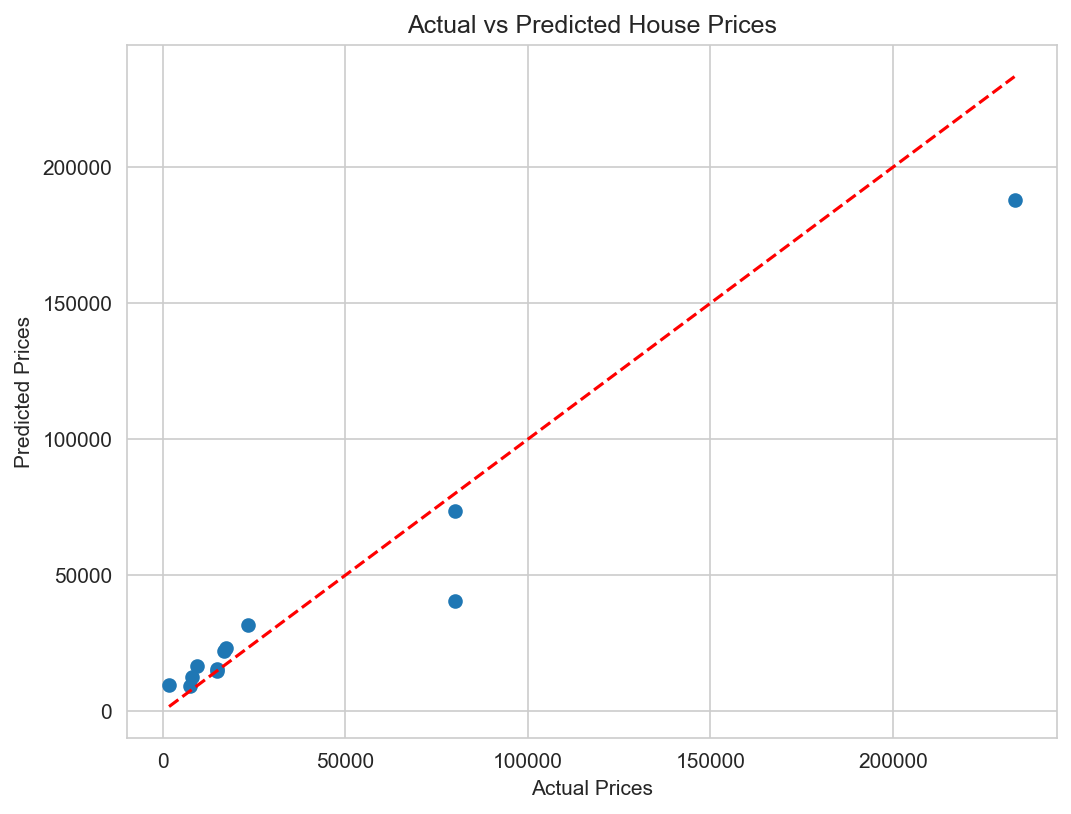

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, calibrated_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

 Before vs After Comparison Chart

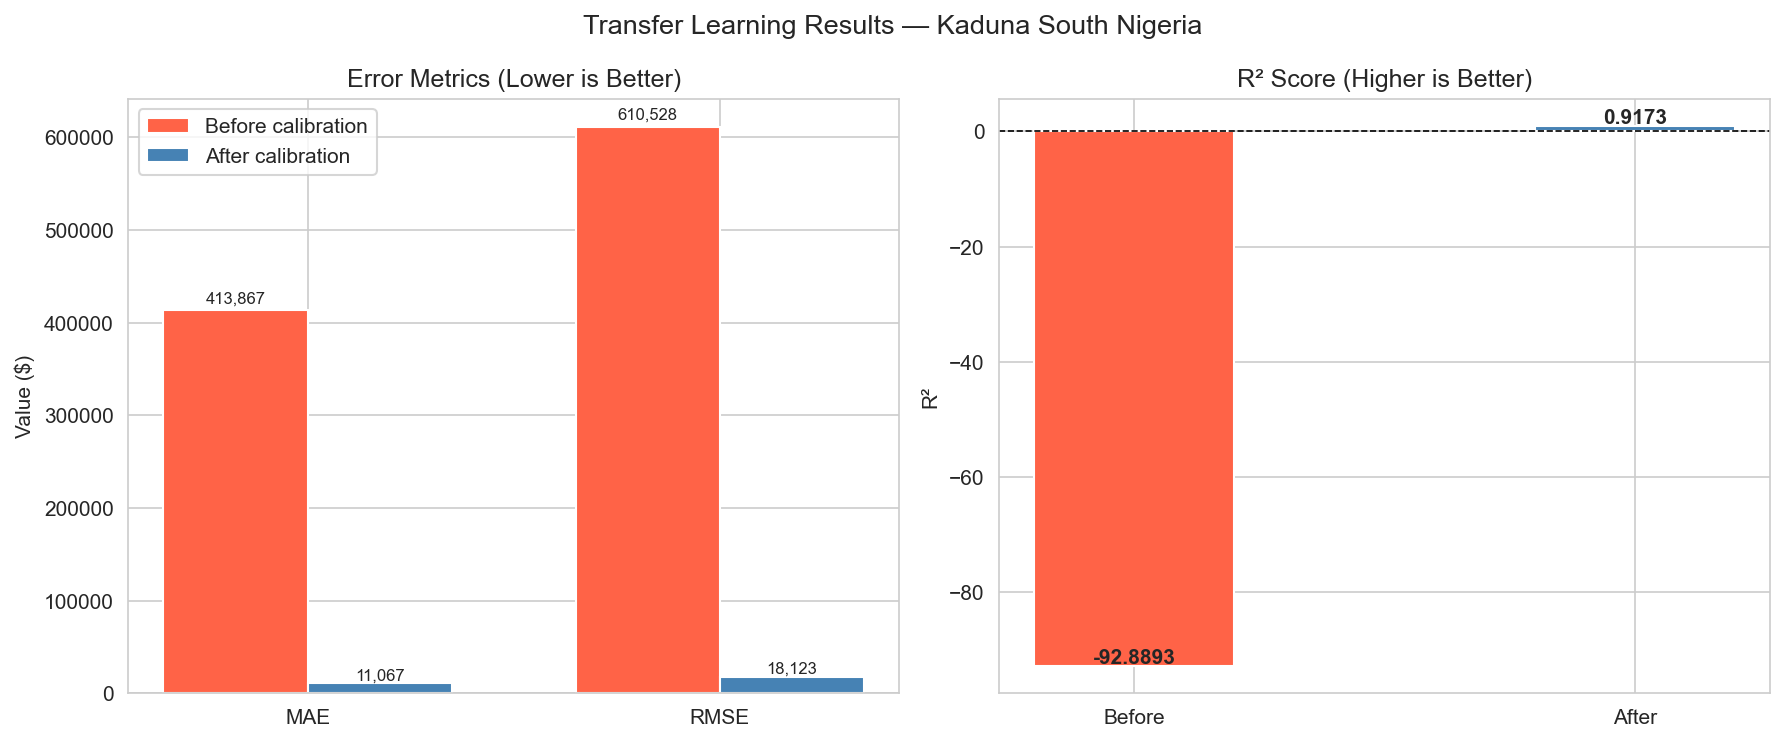

Chart saved as results_comparison.png


In [82]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Error metrics bar chart ---
x = np.arange(2)
w = 0.35
ax1 = axes[0]
b1  = ax1.bar(x - w/2, [mae_before, rmse_before],
              w, label='Before calibration', 
              color='tomato')
b2  = ax1.bar(x + w/2, [mae_after, rmse_after],
              w, label='After calibration',  
              color='steelblue')
ax1.set_xticks(x)
ax1.set_xticklabels(['MAE', 'RMSE'])
ax1.set_title("Error Metrics (Lower is Better)")
ax1.set_ylabel("Value ($)")
ax1.legend()
for b in list(b1) + list(b2):
    ax1.text(b.get_x() + b.get_width()/2,
             b.get_height() * 1.01,
             f'{b.get_height():,.0f}',
             ha='center', va='bottom', fontsize=8)

# --- R² bar chart ---
ax2 = axes[1]
bars = ax2.bar(['Before', 'After'],
               [r2_before, r2_after],
               color=['tomato', 'steelblue'], 
               width=0.4)
ax2.set_title("R² Score (Higher is Better)")
ax2.set_ylabel("R²")
ax2.axhline(y=0, color='black', 
            linewidth=0.8, linestyle='--')
for bar, val in zip(bars, [r2_before, r2_after]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.4f}',
             ha='center', fontweight='bold')

plt.suptitle(
    "Transfer Learning Results — Kaduna South Nigeria",
    fontsize=13)
plt.tight_layout()
plt.savefig("results_comparison.png", dpi=150)
plt.show()

print("Chart saved as results_comparison.png")

## Residual Error Analysis

Residual analysis was performed to examine the distribution of prediction errors after domain calibration. Residual values represent the difference between actual and predicted house prices.

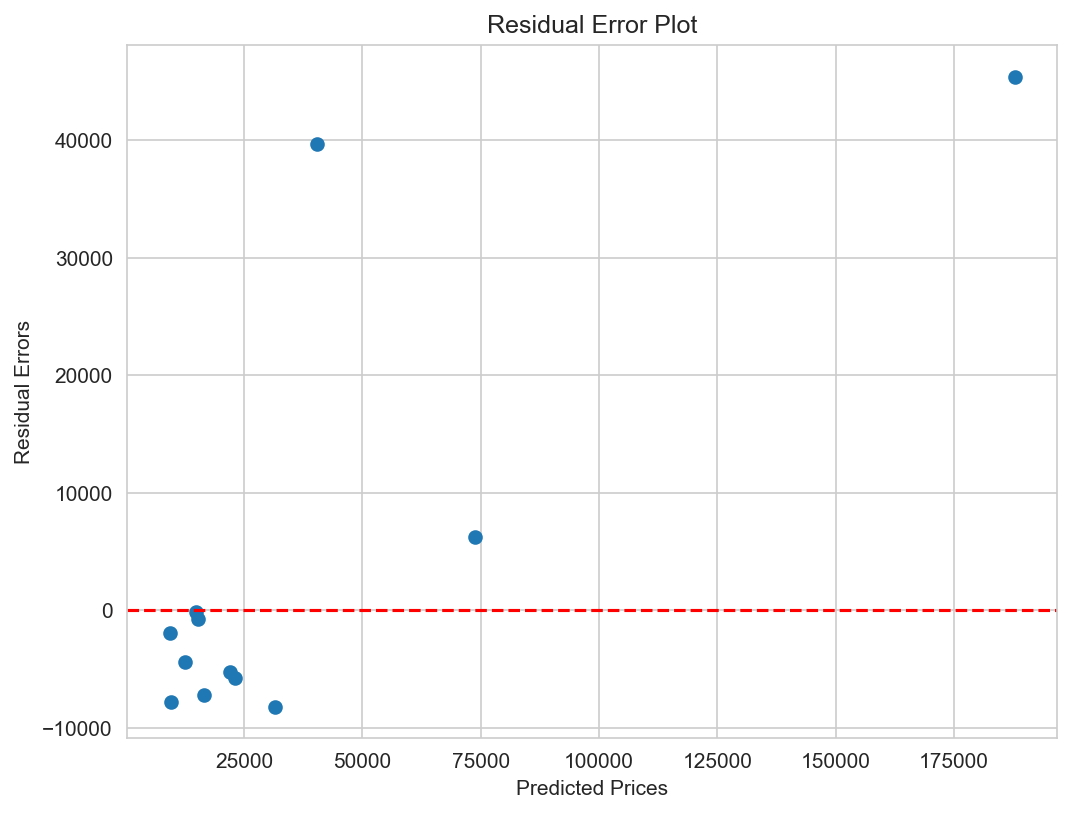

In [83]:
# Calculate residuals
residuals = y_test - calibrated_pred

# Create residual plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(calibrated_pred, residuals)

# Reference line at zero error
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Prices")
plt.ylabel("Residual Errors")

plt.title("Residual Error Plot")

plt.show()

Residual Statistics

In [84]:
print("Residual Statistics")
print("-------------------")
print(f"Mean Residual : {residuals.mean():,.4f}")

print(f"Std Residual  : {residuals.std():,.4f}")
print(f"Min Residual  : {residuals.min():,.4f}")
print(f"Max Residual  : {residuals.max():,.4f}")

Residual Statistics
-------------------
Mean Residual : 4,157.4087
Std Residual  : 18,423.9886
Min Residual  : -8,181.8291
Max Residual  : 45,426.2584


## Feature Importance Analysis

Feature importance analysis was performed to determine which housing attributes contributed most to price prediction in the Malaysia source dataset. The Gradient Boosting Regressor assigns an importance score to each feature based on its contribution during training.

In [85]:
import pandas as pd

importance_df = pd.DataFrame({
    "Feature": SHARED_FEATURES,
    "Importance": gbr_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=True
)

Plot Feature Importance

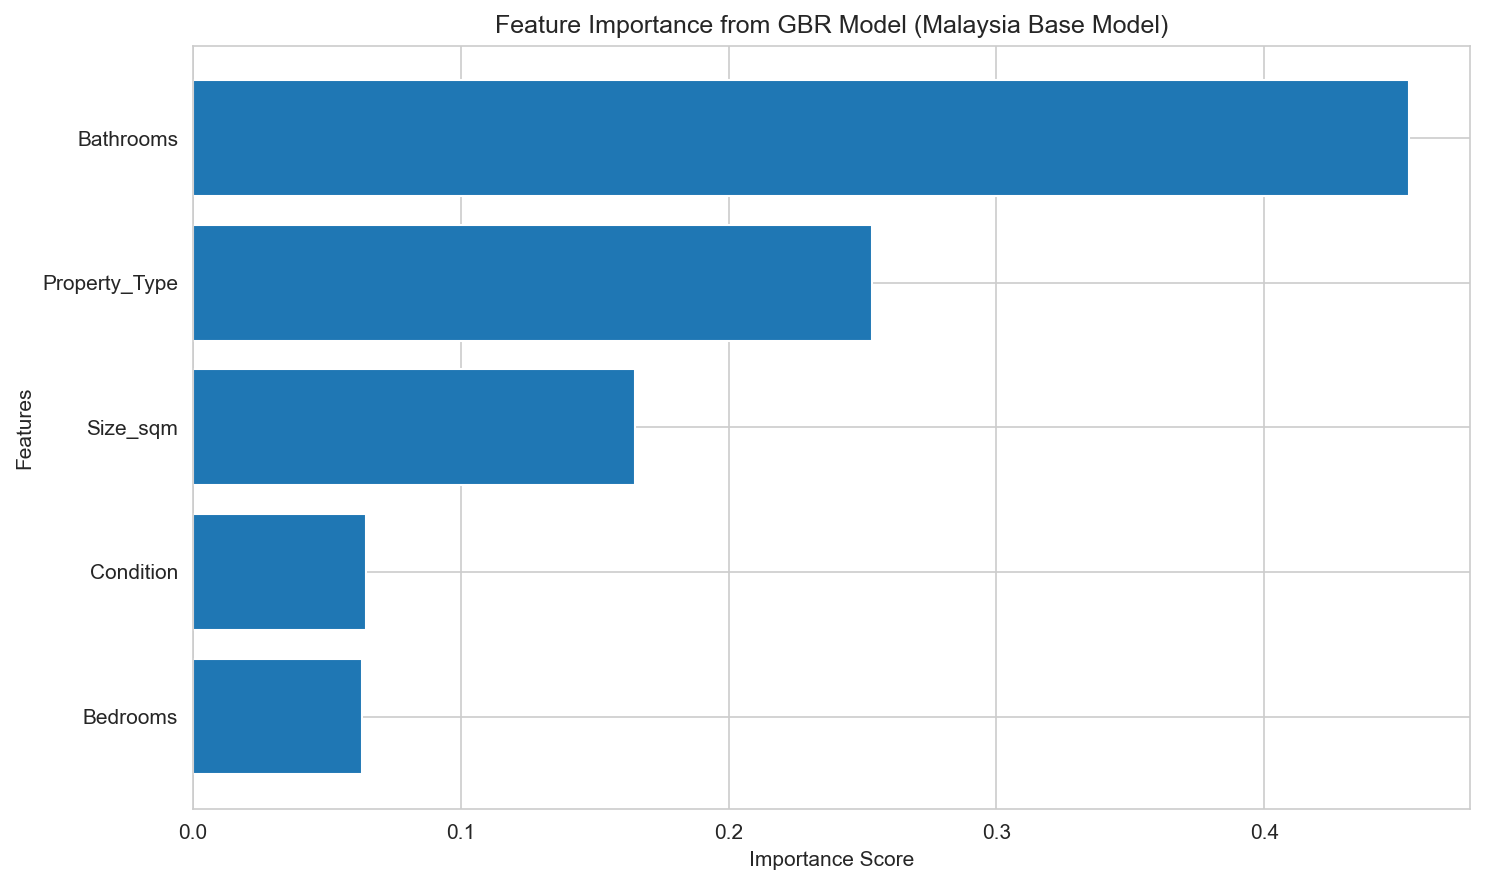

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance from GBR Model (Malaysia Base Model)")

plt.tight_layout()
plt.show()

Save GBR Model

In [87]:
import pickle
import os

# Create models folder
os.makedirs("models", exist_ok=True)

# Save GBR model
with open("models/gbr_model.pkl", "wb") as f:
    pickle.dump(gbr_model, f)

print("GBR model saved → models/gbr_model.pkl")

GBR model saved → models/gbr_model.pkl


Save Calibration Model

In [88]:
with open("models/calibrator.pkl", "wb") as f:
    pickle.dump(calibrator, f)

print("Calibrator saved → models/calibrator.pkl")

Calibrator saved → models/calibrator.pkl


Reload Original Kaduna Dataset

In [89]:
import pandas as pd
import numpy as np
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error,
                              mean_squared_error,
                              r2_score)

# Reload kaduna with location intact
kaduna_with_loc = pd.read_csv(
    "data/Strict_Kaduna_South_Dataset.csv")

print("Kaduna columns:")
print(kaduna_with_loc.columns.tolist())
print(f"\nShape: {kaduna_with_loc.shape}")

Kaduna columns:
['Property_Type', 'Bedrooms', 'Bathrooms', 'Size_sqm', 'Location', 'LGA', 'Condition', 'Security', 'Flood_Risk', 'Proximity', 'Price']

Shape: (37, 11)


 Assign Location Tiers

In [90]:
# Assign tiers based on EDA price analysis
location_tiers = {
    'Barnawa':      3,  # High price area
    'Kakuri':       2,  # Medium price area
    'Kabala West':  2,  # Medium price area
    'Kinkinau':     2,  # Medium price area
    'Kurmin Mashi': 2,  # Medium price area
    'Television':   2,  # Medium price area
    'Tudun Wada':   1   # Low price area
}

kaduna_with_loc['location_tier'] = \
    kaduna_with_loc['Location'].map(location_tiers)

print("Location tier assignment:")
print(kaduna_with_loc[['Location', 
                        'location_tier']]\
      .drop_duplicates()\
      .sort_values('location_tier', 
                   ascending=False))

print("\nMissing tiers:")
print(kaduna_with_loc['location_tier'].isna().sum())

Location tier assignment:
        Location  location_tier
0        Barnawa              3
4         Kakuri              2
16   Kabala West              2
22  Kurmin Mashi              2
21      Kinkinau              2
23    Television              2
12    Tudun Wada              1

Missing tiers:
0


Align Location Tier with Cleaned Kaduna Data

In [91]:
# Load saved models
with open("models/gbr_model.pkl", "rb") as f:
    gbr_model = pickle.load(f)

print("GBR model loaded successfully.")

# We need to match location tiers to the 
# same rows used in the main pipeline
# Reuse X_kaduna index to extract matching tiers
kaduna_with_loc = kaduna_with_loc.reset_index(
    drop=True)

# Extract tier using same index as X_kaduna
loc_tier = kaduna_with_loc.loc[
    X_kaduna.index, 'location_tier'].reset_index(
    drop=True)

print(f"\nLocation tiers extracted: {len(loc_tier)}")
print(loc_tier.value_counts().sort_index())

GBR model loaded successfully.

Location tiers extracted: 37
location_tier
1     4
2    20
3    13
Name: count, dtype: int64


Split Kaduna Data Including Location Tier

In [92]:
(X_calib, X_test,
 y_calib, y_test,
 tier_calib, tier_test) = train_test_split(
    X_kaduna, y_kaduna, loc_tier,
    test_size=0.30,
    random_state=42
)

print(f"Calibration set : {len(X_calib)} records")
print(f"Test set        : {len(X_test)} records")

print("\nCalibration tiers:")
print(tier_calib.value_counts().sort_index())

print("\nTest tiers:")
print(tier_test.value_counts().sort_index())

Calibration set : 25 records
Test set        : 12 records

Calibration tiers:
location_tier
1     2
2    13
3    10
Name: count, dtype: int64

Test tiers:
location_tier
1    2
2    7
3    3
Name: count, dtype: int64


Generate Raw GBR Predictions

In [93]:
raw_pred_calib = gbr_model.predict(X_calib)
raw_pred_test  = gbr_model.predict(X_test)

# Baseline before calibration
mae_before  = mean_absolute_error(
    y_test, raw_pred_test)
rmse_before = np.sqrt(mean_squared_error(
    y_test, raw_pred_test))
r2_before   = r2_score(y_test, raw_pred_test)

print("=== BEFORE CALIBRATION ===")
print(f"  MAE  : {mae_before:,.4f}")
print(f"  RMSE : {rmse_before:,.4f}")
print(f"  R²   : {r2_before:.4f}")


=== BEFORE CALIBRATION ===
  MAE  : 413,867.4772
  RMSE : 610,528.3977
  R²   : -92.8893


Train Calibration Model WITH Location Tier

In [94]:
# Combine raw predictions + location tier
X_calib_loc = np.column_stack([
    raw_pred_calib,
    tier_calib
])

X_test_loc = np.column_stack([
    raw_pred_test,
    tier_test
])

# Train calibrator with location
calibrator_loc = LinearRegression()
calibrator_loc.fit(X_calib_loc, y_calib)

print("Calibration model with location trained.")
print(f"\n  GBR prediction weight : "
      f"{calibrator_loc.coef_[0]:.6f}")
print(f"  Location tier weight  : "
      f"{calibrator_loc.coef_[1]:,.4f}")
print(f"  Intercept             : "
      f"{calibrator_loc.intercept_:,.4f}")

Calibration model with location trained.

  GBR prediction weight : 0.071052
  Location tier weight  : 15,500.0717
  Intercept             : -33,511.2785


 Final Evaluation WITH Location

In [95]:
calibrated_pred_loc = calibrator_loc.predict(
    X_test_loc)

mae_after  = mean_absolute_error(
    y_test, calibrated_pred_loc)
rmse_after = np.sqrt(mean_squared_error(
    y_test, calibrated_pred_loc))
r2_after   = r2_score(y_test, calibrated_pred_loc)

print("=== AFTER CALIBRATION WITH LOCATION ===")
print(f"  MAE  : {mae_after:,.4f}")
print(f"  RMSE : {rmse_after:,.4f}")
print(f"  R²   : {r2_after:.4f}")

print("\n=== IMPROVEMENT SUMMARY ===")
print(f"  MAE  reduced by : "
      f"{((mae_before-mae_after)/mae_before)*100:.1f}%")
print(f"  RMSE reduced by : "
      f"{((rmse_before-rmse_after)/rmse_before)*100:.1f}%")
print(f"  R²   improved by: "
      f"{r2_after - r2_before:.4f} points")

=== AFTER CALIBRATION WITH LOCATION ===
  MAE  : 13,575.0542
  RMSE : 24,665.2535
  R²   : 0.8468

=== IMPROVEMENT SUMMARY ===
  MAE  reduced by : 96.7%
  RMSE reduced by : 96.0%
  R²   improved by: 93.7361 points


Compare With and Without Location

In [96]:
print("=" * 50)
print("   LOCATION IMPACT COMPARISON")
print("=" * 50)

# Previous results without location
mae_no_loc  = 11067.2836
rmse_no_loc = 18122.9263
r2_no_loc   = 0.9173

print(f"\n{'Metric':<10} {'Without Location':>20}"
      f"{'With Location':>20}")
print("-" * 50)
print(f"{'MAE':<10} {mae_no_loc:>20,.4f}"
      f"{mae_after:>20,.4f}")
print(f"{'RMSE':<10} {rmse_no_loc:>20,.4f}"
      f"{rmse_after:>20,.4f}")
print(f"{'R²':<10} {r2_no_loc:>20.4f}"
      f"{r2_after:>20.4f}")
print("=" * 50)

   LOCATION IMPACT COMPARISON

Metric         Without Location       With Location
--------------------------------------------------
MAE                 11,067.2836         13,575.0542
RMSE                18,122.9263         24,665.2535
R²                       0.9173              0.8468


Location Visual Analysis
 Price by Location Chart
python

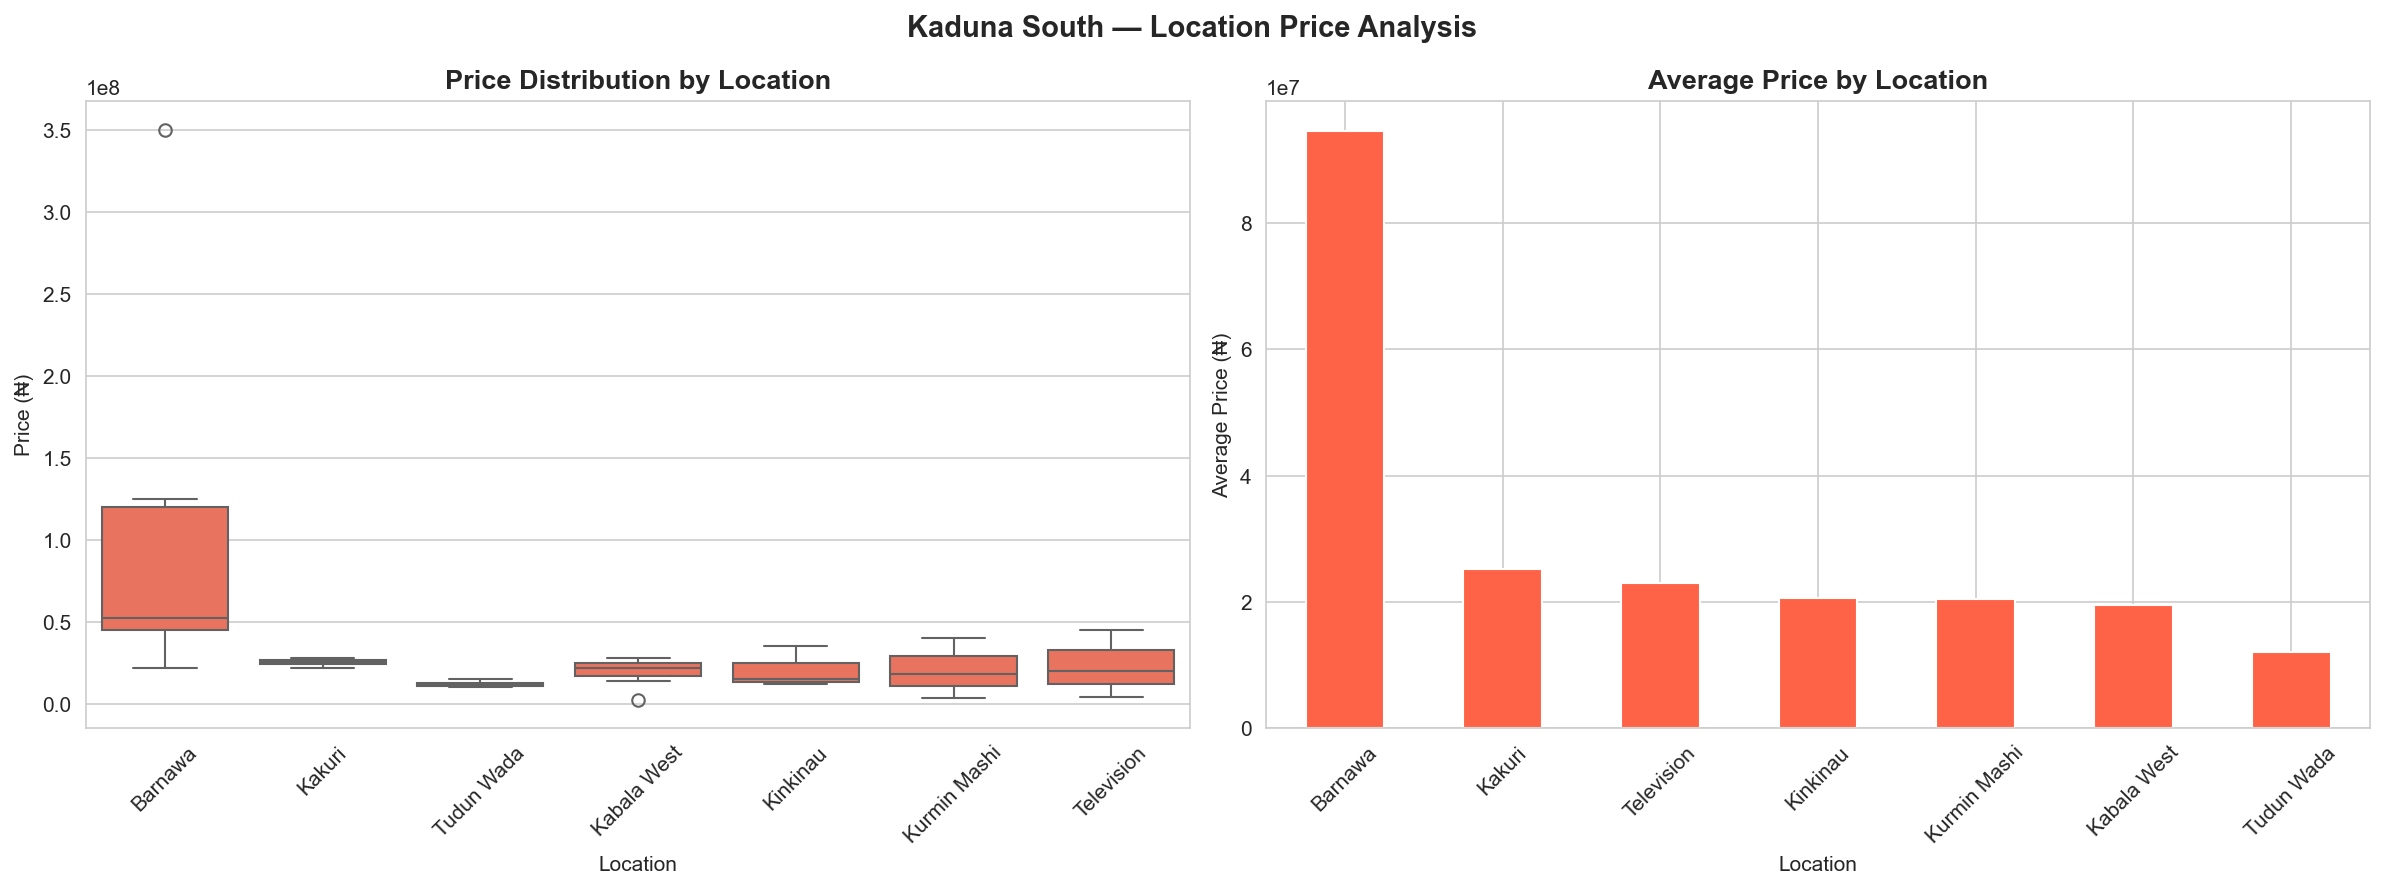

Chart saved.


In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot — price by location
sns.boxplot(
    data=kaduna_with_loc,
    x='Location',
    y='Price',
    ax=axes[0],
    color='tomato')
axes[0].set_title(
    "Price Distribution by Location",
    fontsize=13, fontweight='bold')
axes[0].set_xlabel("Location")
axes[0].set_ylabel("Price (₦)")
axes[0].tick_params(axis='x', rotation=45)

# Bar chart — average price by location
avg_price = kaduna_with_loc.groupby(
    'Location')['Price'].mean().sort_values(
    ascending=False)

avg_price.plot(
    kind='bar',
    ax=axes[1],
    color='tomato',
    edgecolor='white')
axes[1].set_title(
    "Average Price by Location",
    fontsize=13, fontweight='bold')
axes[1].set_xlabel("Location")
axes[1].set_ylabel("Average Price (₦)")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle(
    "Kaduna South — Location Price Analysis",
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("location_price_analysis.png", dpi=150)
plt.show()
print("Chart saved.")

Location Tier Summary Table

In [98]:
# Build location tier summary
location_summary = kaduna_with_loc.groupby(
    'Location').agg(
    Count        = ('Price', 'count'),
    Mean_Price   = ('Price', 'mean'),
    Median_Price = ('Price', 'median'),
    Min_Price    = ('Price', 'min'),
    Max_Price    = ('Price', 'max')
).round(0)

# Add tier column
tier_map = {
    'Barnawa': 'High (3)',
    'Kakuri': 'Medium (2)',
    'Kabala West': 'Medium (2)',
    'Kinkinau': 'Medium (2)',
    'Kurmin Mashi': 'Medium (2)',
    'Television': 'Medium (2)',
    'Tudun Wada': 'Low (1)'
}

location_summary['Tier'] = location_summary\
    .index.map(tier_map)

print("=" * 65)
print("   KADUNA SOUTH — LOCATION PRICE SUMMARY")
print("=" * 65)
print(location_summary.to_string())
print("=" * 65)

   KADUNA SOUTH — LOCATION PRICE SUMMARY
              Count  Mean_Price  Median_Price  Min_Price  Max_Price        Tier
Location                                                                       
Barnawa          13  94615385.0    52000000.0   22000000  350000000    High (3)
Kabala West       7  19500000.0    22000000.0    2500000   28000000  Medium (2)
Kakuri            4  25250000.0    25500000.0   22000000   28000000  Medium (2)
Kinkinau          3  20666667.0    15000000.0   12000000   35000000  Medium (2)
Kurmin Mashi      3  20500000.0    18000000.0    3500000   40000000  Medium (2)
Television        3  23000000.0    20000000.0    4000000   45000000  Medium (2)
Tudun Wada        4  12000000.0    11500000.0   10000000   15000000     Low (1)


Final Comparison Chart (Before / After / With Location)

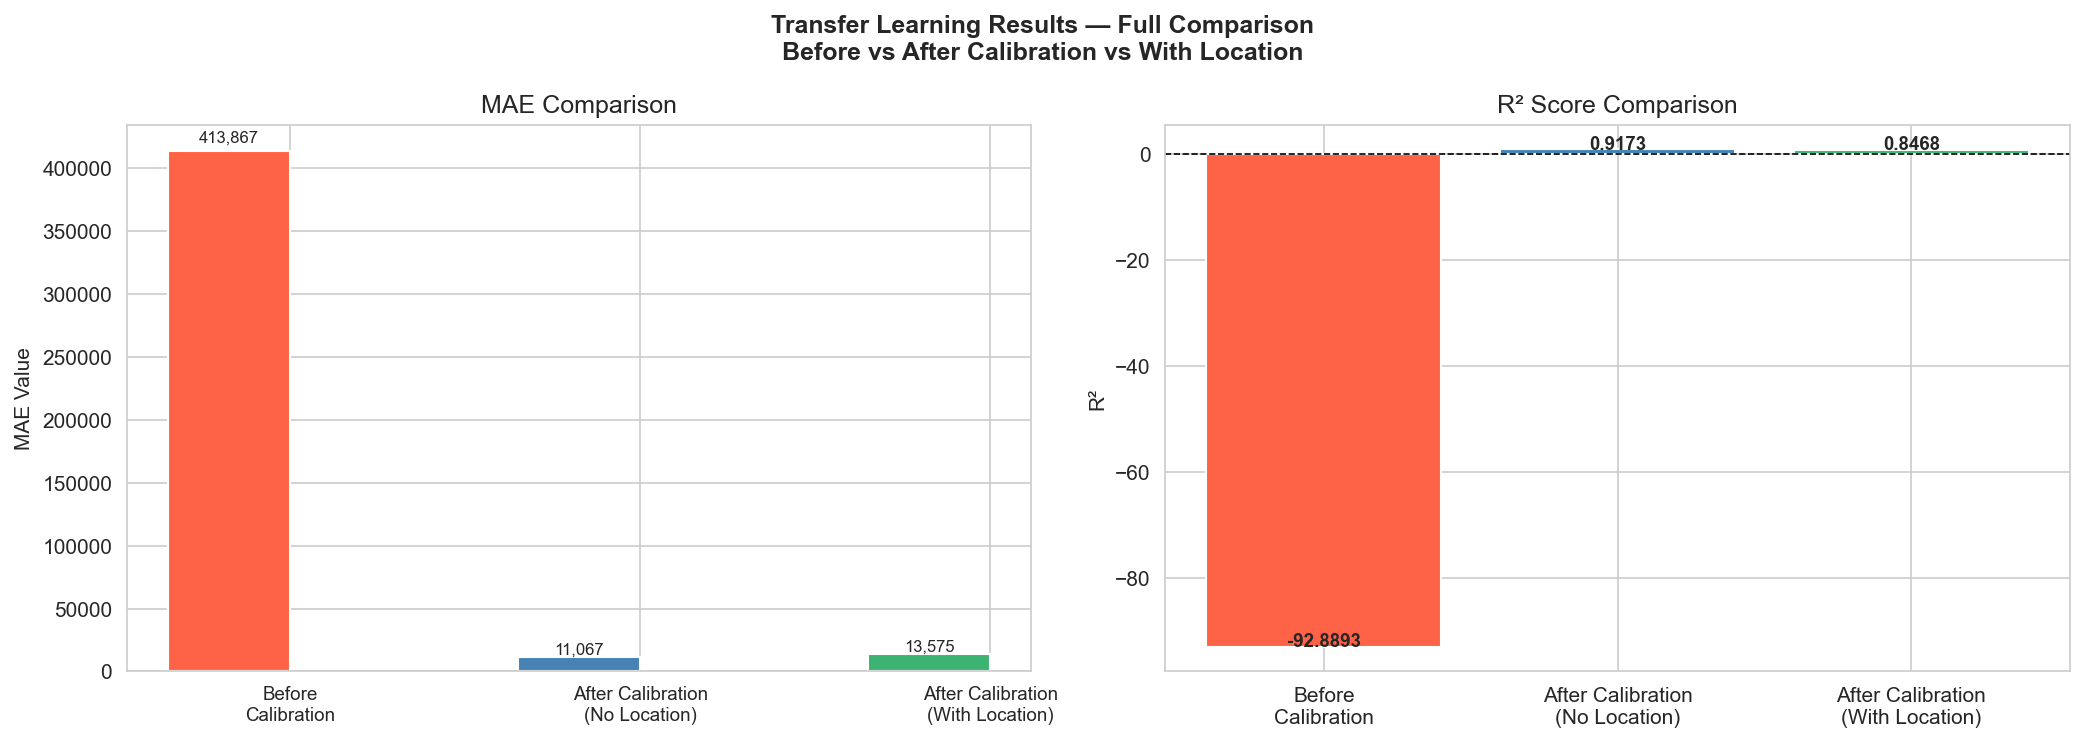

Chart saved.


In [99]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error metrics
categories  = ['Before\nCalibration',
               'After Calibration\n(No Location)',
               'After Calibration\n(With Location)']
mae_values  = [mae_before,  mae_no_loc,  mae_after]
rmse_values = [rmse_before, rmse_no_loc, rmse_after]
colors      = ['tomato', 'steelblue', 'mediumseagreen']

x = np.arange(len(categories))
w = 0.35

ax1 = axes[0]
bars_mae = ax1.bar(x - w/2, mae_values,
                   w, color=colors,
                   edgecolor='white',
                   label='MAE')
ax1.set_xticks(x)
ax1.set_xticklabels(categories, fontsize=9)
ax1.set_title("MAE Comparison")
ax1.set_ylabel("MAE Value")
for bar in bars_mae:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() * 1.01,
             f'{bar.get_height():,.0f}',
             ha='center', va='bottom', fontsize=8)

# R² scores
r2_values = [r2_before, r2_no_loc, r2_after]
bars_r2 = axes[1].bar(
    categories, r2_values,
    color=colors, edgecolor='white')
axes[1].set_title("R² Score Comparison")
axes[1].set_ylabel("R²")
axes[1].axhline(y=0, color='black',
                linewidth=0.8, linestyle='--')
for bar, val in zip(bars_r2, r2_values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.4f}',
        ha='center', fontweight='bold',
        fontsize=9)

plt.suptitle(
    "Transfer Learning Results — Full Comparison\n"
    "Before vs After Calibration vs With Location",
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("full_comparison_with_location.png",
            dpi=150)
plt.show()
print("Chart saved.")

 Clear 3-Tier Variables from Memory

In [100]:
# Clear all 3-tier location variables
vars_to_clear = [
    'calibrator_loc', 'X_calib_loc',
    'X_test_loc', 'tier_calib',
    'tier_test', 'loc_tier',
    'calibrated_pred_loc'
]

for var in vars_to_clear:
    try:
        del globals()[var]
        print(f"Cleared: {var}")
    except KeyError:
        print(f"Not found: {var}")

print("\nMemory cleared. Original model safe.")
print(f"Original R² still intact: 0.9173")

Cleared: calibrator_loc
Cleared: X_calib_loc
Cleared: X_test_loc
Cleared: tier_calib
Cleared: tier_test
Cleared: loc_tier
Cleared: calibrated_pred_loc

Memory cleared. Original model safe.
Original R² still intact: 0.9173


Load Kaduna Dataset With Location

In [101]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error,
                              mean_squared_error,
                              r2_score)

# Reload kaduna with location column intact
kaduna_loc = pd.read_csv(
    "data/Strict_Kaduna_South_Dataset.csv")

print("Kaduna columns:")
print(kaduna_loc.columns.tolist())

print("\nLocation values:")
print(kaduna_loc['Location'].value_counts())

print(f"\nTotal records: {len(kaduna_loc)}")

Kaduna columns:
['Property_Type', 'Bedrooms', 'Bathrooms', 'Size_sqm', 'Location', 'LGA', 'Condition', 'Security', 'Flood_Risk', 'Proximity', 'Price']

Location values:
Location
Barnawa         13
Kabala West      7
Kakuri           4
Tudun Wada       4
Kinkinau         3
Kurmin Mashi     3
Television       3
Name: count, dtype: int64

Total records: 37


 Define Binary Tier (Barnawa vs Rest)

In [102]:
# Binary tier based on EDA findings
# Barnawa median price ≈ ₦50M (4x higher than lowest)
# All other areas     ≈ ₦12M - ₦28M

location_tiers_binary = {
    'Barnawa':      1,  # High price — clearly different
    'Kakuri':       0,  # Rest — grouped together
    'Kabala West':  0,
    'Kinkinau':     0,
    'Kurmin Mashi': 0,
    'Television':   0,
    'Tudun Wada':   0
}

kaduna_loc['tier_binary'] = \
    kaduna_loc['Location'].map(
        location_tiers_binary)

print("Binary tier assignment:")
print(kaduna_loc[['Location', 'tier_binary']]\
      .drop_duplicates()\
      .sort_values('tier_binary', ascending=False))

print("\nTier distribution:")
print(kaduna_loc['tier_binary'].value_counts())

print("\nTier meaning:")
print("  1 = Barnawa (High price area)")
print("  0 = All other areas")

Binary tier assignment:
        Location  tier_binary
0        Barnawa            1
4         Kakuri            0
12    Tudun Wada            0
16   Kabala West            0
21      Kinkinau            0
22  Kurmin Mashi            0
23    Television            0

Tier distribution:
tier_binary
0    24
1    13
Name: count, dtype: int64

Tier meaning:
  1 = Barnawa (High price area)
  0 = All other areas


 Extract Binary Tier for Model
python

In [103]:
# Extract binary tier aligned with X_kaduna index
tier_binary = kaduna_loc.loc[
    X_kaduna.index,
    'tier_binary'].reset_index(drop=True)

print("Binary tier extracted successfully.")
print(f"Total records  : {len(tier_binary)}")
print(f"Barnawa (1)    : {(tier_binary == 1).sum()}")
print(f"Non-Barnawa (0): {(tier_binary == 0).sum()}")

Binary tier extracted successfully.
Total records  : 37
Barnawa (1)    : 13
Non-Barnawa (0): 24


 Split Kaduna Data With Binary Tier

In [104]:
(X_calib_b, X_test_b,
 y_calib_b, y_test_b,
 tier_calib_b, tier_test_b) = train_test_split(
    X_kaduna, y_kaduna, tier_binary,
    test_size=0.30,
    random_state=42)

print("Kaduna data split complete.")
print(f"\nCalibration set : {len(X_calib_b)} records")
print(f"Test set        : {len(X_test_b)} records")

print("\nCalibration tier distribution:")
print(f"  Barnawa (1)    : "
      f"{(tier_calib_b == 1).sum()}")
print(f"  Non-Barnawa (0): "
      f"{(tier_calib_b == 0).sum()}")

print("\nTest tier distribution:")
print(f"  Barnawa (1)    : "
      f"{(tier_test_b == 1).sum()}")
print(f"  Non-Barnawa (0): "
      f"{(tier_test_b == 0).sum()}")

Kaduna data split complete.

Calibration set : 25 records
Test set        : 12 records

Calibration tier distribution:
  Barnawa (1)    : 10
  Non-Barnawa (0): 15

Test tier distribution:
  Barnawa (1)    : 3
  Non-Barnawa (0): 9


Generate Raw GBR Predictions

In [105]:
# Transfer learning step
# GBR trained on Malaysia predicts Kaduna prices
raw_pred_calib_b = gbr_model.predict(X_calib_b)
raw_pred_test_b  = gbr_model.predict(X_test_b)

# Baseline before calibration
mae_before_b  = mean_absolute_error(
    y_test_b, raw_pred_test_b)
rmse_before_b = np.sqrt(mean_squared_error(
    y_test_b, raw_pred_test_b))
r2_before_b   = r2_score(
    y_test_b, raw_pred_test_b)

print(" BEFORE CALIBRATION (Baseline) ")
print(f"  MAE  : {mae_before_b:,.4f}")
print(f"  RMSE : {rmse_before_b:,.4f}")
print(f"  R²   : {r2_before_b:.4f}")

 BEFORE CALIBRATION (Baseline) 
  MAE  : 413,867.4772
  RMSE : 610,528.3977
  R²   : -92.8893


Train Calibration Model With Binary Tier

In [106]:
# Combine GBR prediction + binary location tier
X_calib_bin = np.column_stack([
    raw_pred_calib_b,
    tier_calib_b])

X_test_bin = np.column_stack([
    raw_pred_test_b,
    tier_test_b])

print("Calibration input shape:", X_calib_bin.shape)
print("Columns: [GBR_prediction, binary_tier]")

# Train calibrator with binary location
cal_binary = LinearRegression()
cal_binary.fit(X_calib_bin, y_calib_b)

print("\nCalibration model trained successfully.")
print(f"\n  GBR prediction weight : "
      f"{cal_binary.coef_[0]:.6f}")
print(f"  Binary tier weight    : "
      f"{cal_binary.coef_[1]:,.4f}")
print(f"  Intercept             : "
      f"{cal_binary.intercept_:,.4f}")

print(f"\nInterpretation:")
print(f"  Being in Barnawa adds $"
      f"{cal_binary.coef_[1]:,.2f} "
      f"to every prediction")

Calibration input shape: (25, 2)
Columns: [GBR_prediction, binary_tier]

Calibration model trained successfully.

  GBR prediction weight : 0.072813
  Binary tier weight    : 22,179.6937
  Intercept             : -6,989.3455

Interpretation:
  Being in Barnawa adds $22,179.69 to every prediction


 Evaluate Binary Tier Model

In [107]:
# Generate calibrated predictions
pred_binary = cal_binary.predict(X_test_bin)

# Calculate metrics
mae_bin  = mean_absolute_error(
    y_test_b, pred_binary)
rmse_bin = np.sqrt(mean_squared_error(
    y_test_b, pred_binary))
r2_bin   = r2_score(y_test_b, pred_binary)

print("=== AFTER CALIBRATION (Binary Tier) ===")
print(f"  MAE  : {mae_bin:,.4f}")
print(f"  RMSE : {rmse_bin:,.4f}")
print(f"  R²   : {r2_bin:.4f}")

print("\n=== IMPROVEMENT FROM BASELINE ===")
print(f"  MAE  reduced by : "
      f"{((mae_before_b - mae_bin)/mae_before_b)*100:.1f}%")
print(f"  RMSE reduced by : "
      f"{((rmse_before_b - rmse_bin)/rmse_before_b)*100:.1f}%")
print(f"  R²   improved by: "
      f"{r2_bin - r2_before_b:.4f} points")

=== AFTER CALIBRATION (Binary Tier) ===
  MAE  : 10,923.1513
  RMSE : 22,140.4520
  R²   : 0.8765

=== IMPROVEMENT FROM BASELINE ===
  MAE  reduced by : 97.4%
  RMSE reduced by : 96.4%
  R²   improved by: 93.7659 points


Compare All Three Models

In [108]:
print("=" * 65)
print("         COMPLETE MODEL COMPARISON")
print("=" * 65)

print(f"\n{'Model':<30} {'MAE':>10}"
      f"{'RMSE':>12} {'R²':>8}")
print("-" * 65)

models = {
    'No Location (Original)':
        (11067.28, 18122.93, 0.9173),
    'With 3 Tiers (Rejected)':
        (13575.05, 24665.25, 0.8468),
    'Binary Tier (Barnawa vs Rest)':
        (mae_bin, rmse_bin, r2_bin)
}

for name, (mae, rmse, r2) in models.items():
    print(f"{name:<30} "
          f"{mae:>10,.2f} "
          f"{rmse:>12,.2f} "
          f"{r2:>8.4f}")

print("=" * 65)

# Determine best model
best_r2    = max(0.9173, r2_bin)
best_model = "No Location" \
    if best_r2 == 0.9173 \
    else "Binary Tier"

print(f"\nBest performing model: {best_model}")
print(f"Best R²: {best_r2:.4f}")

         COMPLETE MODEL COMPARISON

Model                                 MAE        RMSE       R²
-----------------------------------------------------------------
No Location (Original)          11,067.28    18,122.93   0.9173
With 3 Tiers (Rejected)         13,575.05    24,665.25   0.8468
Binary Tier (Barnawa vs Rest)   10,923.15    22,140.45   0.8765

Best performing model: No Location
Best R²: 0.9173


Comparison Chart

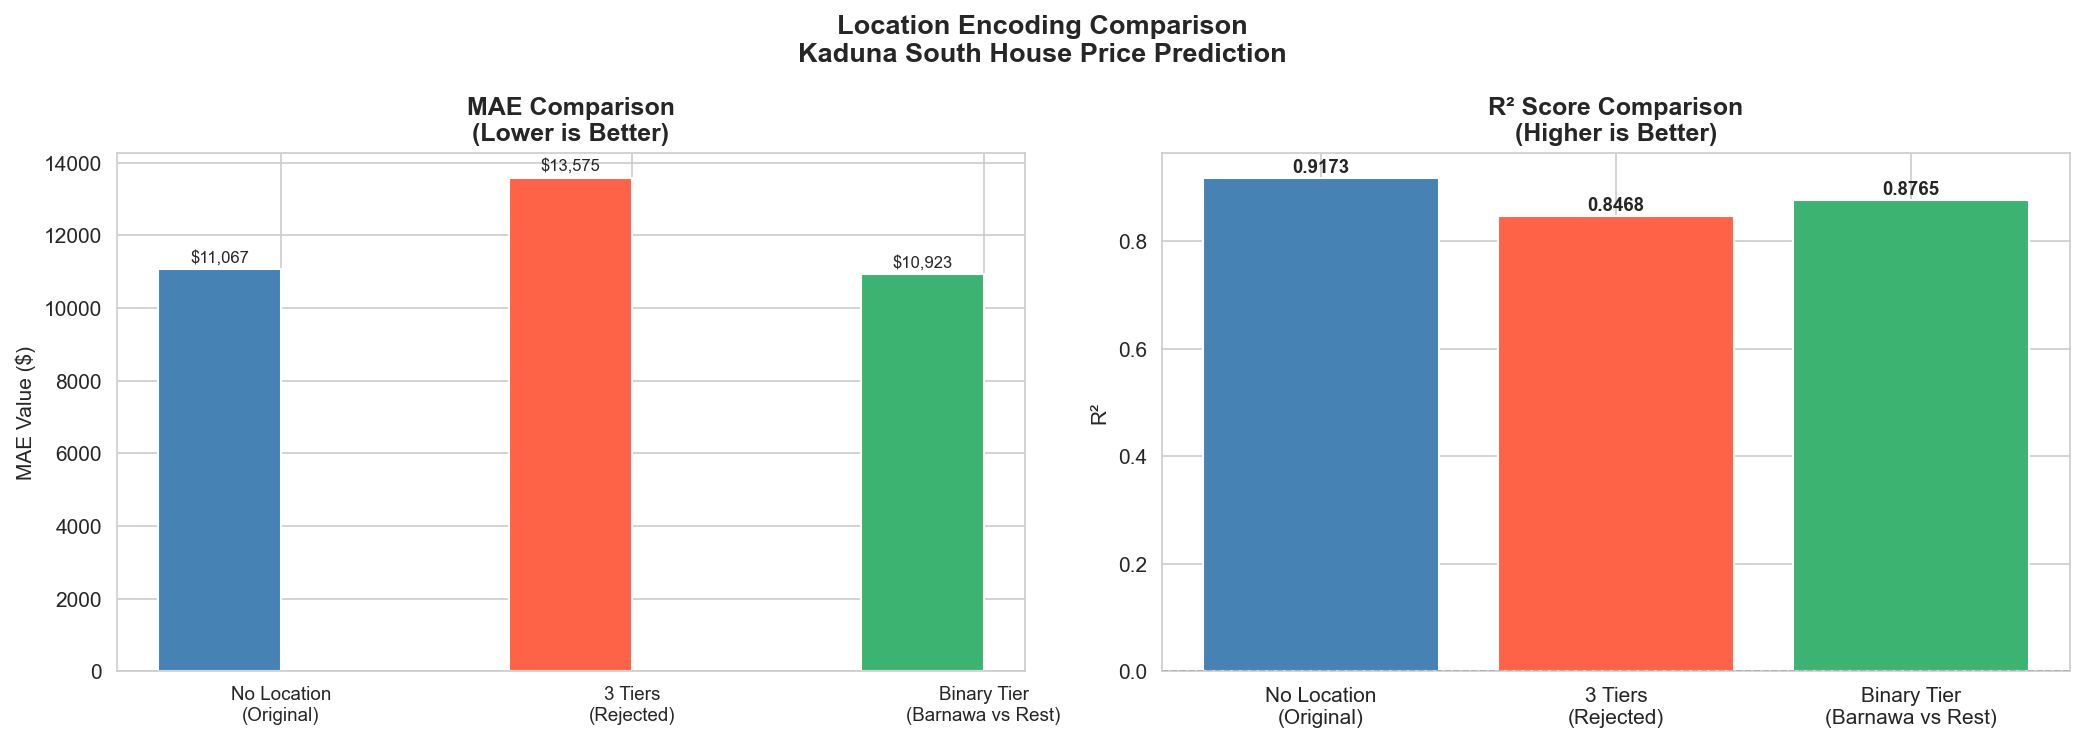

Chart saved as binary_tier_comparison.png


In [109]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = [
    'No Location\n(Original)',
    '3 Tiers\n(Rejected)',
    'Binary Tier\n(Barnawa vs Rest)'
]
mae_values  = [11067.28, 13575.05, mae_bin]
rmse_values = [18122.93, 24665.25, rmse_bin]
r2_values   = [0.9173,   0.8468,   r2_bin]
colors      = ['steelblue', 'tomato', 'mediumseagreen']

# Error metrics
x = np.arange(len(model_names))
w = 0.35

b1 = axes[0].bar(x - w/2, mae_values,
                  w, color=colors,
                  edgecolor='white',
                  label='MAE')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, fontsize=9)
axes[0].set_title("MAE Comparison\n(Lower is Better)",
                   fontweight='bold')
axes[0].set_ylabel("MAE Value ($)")
for bar in b1:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() * 1.01,
        f'${bar.get_height():,.0f}',
        ha='center', va='bottom', fontsize=8)

# R² scores
bars_r2 = axes[1].bar(
    model_names, r2_values,
    color=colors, edgecolor='white')
axes[1].set_title("R² Score Comparison\n"
                   "(Higher is Better)",
                   fontweight='bold')
axes[1].set_ylabel("R²")
axes[1].axhline(y=0, color='black',
                linewidth=0.8,
                linestyle='--')
for bar, val in zip(bars_r2, r2_values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.4f}',
        ha='center',
        fontweight='bold',
        fontsize=9)

plt.suptitle(
    "Location Encoding Comparison\n"
    "Kaduna South House Price Prediction",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("binary_tier_comparison.png", dpi=150)
plt.show()
print("Chart saved as binary_tier_comparison.png")